# Neural Networks Final Project - Part A
This notebook analyzes electrical signal recordings of Spiny and Aspiny neurons. The analysis is done based on the provided project requirements.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.stats import norm
import os
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [15]:
# ---------------------------------------------------------
# Data Loading Section
# ---------------------------------------------------------
file_path = "neurodata.npy"
fs = 50000  # 50 KHz sampling rate

print(f"Loading real data from {file_path}...")
data = np.load(file_path)

# neurodata.npy is a 2D array of shape (3, 401000).
# Based on peak analysis, row 1 has a higher firing rate, making it the aspiny neuron.
# Row 2 has a lower firing rate, making it the spiny neuron.
stimulus = data[0]
aspiny_response = data[1]
spiny_response = data[2]

time_vector = np.arange(len(stimulus)) / fs
print("Data is ready.")

Loading real data from neurodata.npy...
Data is ready.


### 1. Spiny and Aspiny Neurons

*   **Spiny Neurons:** These neurons have dendritic spines (small membranous protrusions) that receive synaptic input. They are typically excitatory neurons (such as pyramidal cells in the cerebral cortex) and use glutamate as their primary neurotransmitter. Spines help increase the surface area for synapses.
*   **Aspiny Neurons:** These neurons lack dendritic spines (smooth dendrites). In the cerebral cortex, they are most commonly inhibitory interneurons (e.g., basket cells) that release GABA. They often have higher baseline firing rates and play a crucial role in regulating and modulating the activity of excitatory circuits.

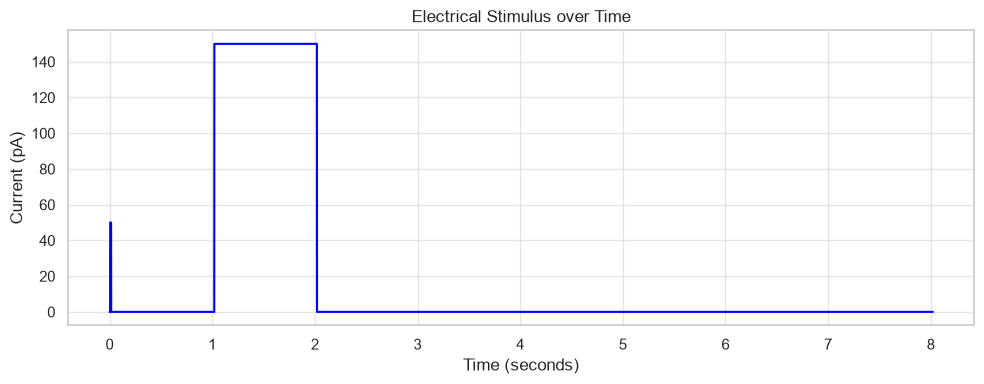

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(time_vector, stimulus, color='blue')
plt.title('Electrical Stimulus over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Current (pA)')
plt.tight_layout()
plt.show()

**Stimulus Description:**
The stimulus represents an injected electrical current (measured in pA) over time. As seen in the graph, it steps up to a constant positive value (e.g., 150 pA) for a specific duration (1 second from 1.02s to 2.02s) and then returns to 0 pA. This depolarizes the neuron, prompting it to fire.

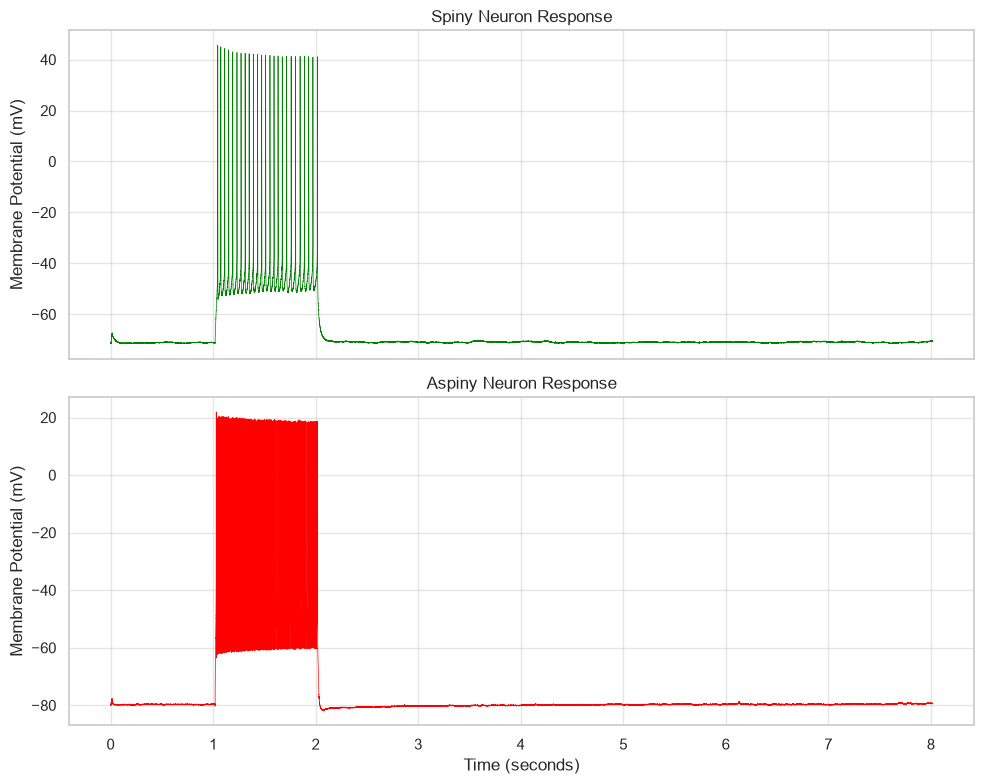

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(time_vector, spiny_response, color='green', linewidth=0.5)
ax[0].set_title('Spiny Neuron Response')
ax[0].set_ylabel('Membrane Potential (mV)')

ax[1].plot(time_vector, aspiny_response, color='red', linewidth=0.5)
ax[1].set_title('Aspiny Neuron Response')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Membrane Potential (mV)')

plt.tight_layout()
plt.show()

**Response Description & Differences:**
Both neurons fire action potentials (spikes) in response to the electrical stimulus. 
The main difference is the **firing rate**. The aspiny neuron exhibits a noticeably higher frequency of action potentials compared to the spiny neuron. The spiny neuron responds with fewer, more spaced-out spikes, while the aspiny neuron fires rapidly, which is characteristic of many fast-spiking inhibitory interneurons.

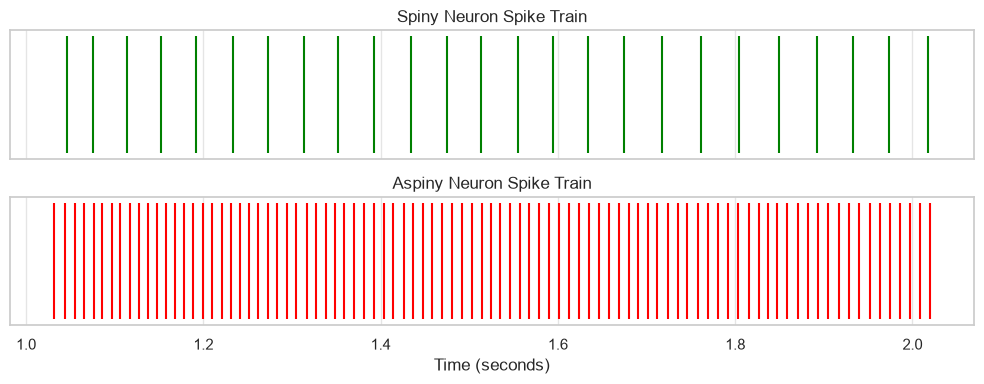

In [25]:
# Function to extract spike times
def extract_spikes(voltage_trace, threshold_mv=-20, min_distance_samples=100):
    peaks, _ = signal.find_peaks(voltage_trace, height=threshold_mv, distance=min_distance_samples)
    return peaks

# We select a safe threshold of -20 mV
threshold = -20 

spiny_peaks = extract_spikes(spiny_response, threshold)
aspiny_peaks = extract_spikes(aspiny_response, threshold)

# Create raster plots for spike trains
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].vlines(time_vector[spiny_peaks], ymin=0, ymax=1, color='green')
ax[0].set_title('Spiny Neuron Spike Train')
ax[0].set_yticks([])

ax[1].vlines(time_vector[aspiny_peaks], ymin=0, ymax=1, color='red')
ax[1].set_title('Aspiny Neuron Spike Train')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

**Threshold Selection:**
The threshold chosen for detecting action potentials is `-20 mV`. 
*   **If the threshold was too low (e.g., -60 mV):** We would falsely detect noise or small subthreshold fluctuations as spikes, leading to an artificially high firing rate and corrupted spike statistics.
*   **If the threshold was too high (e.g., +40 mV):** We might miss genuine action potentials that don't peak extremely high, leading to an artificially low firing rate and missed spikes. `-20 mV` safely separates the resting potential noise from the distinct peak of a spike.

Spiny Neuron CV: 0.070
Aspiny Neuron CV: 0.049


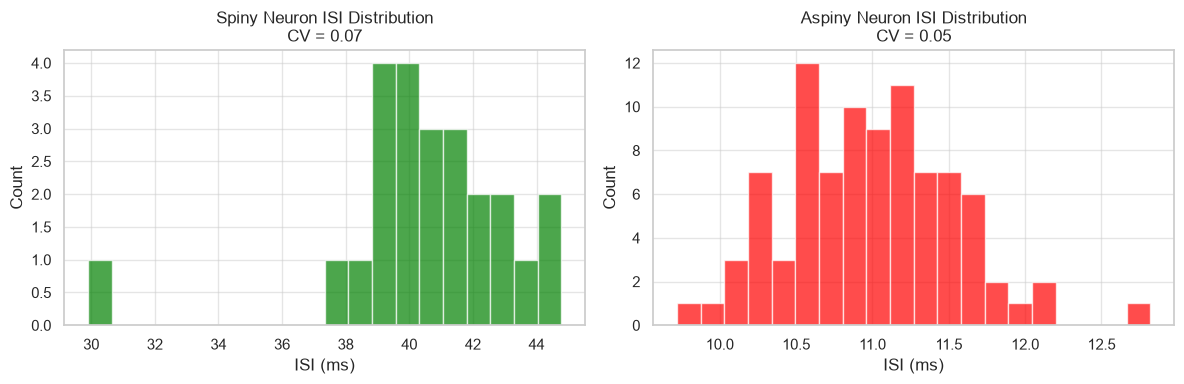

In [26]:
# Calculate ISI (Inter-Spike Intervals) in seconds
spiny_isi = np.diff(spiny_peaks) / fs
aspiny_isi = np.diff(aspiny_peaks) / fs

# Calculate CV (Coefficient of Variation) = std / mean
spiny_cv = np.std(spiny_isi) / np.mean(spiny_isi) if len(spiny_isi) > 0 else 0
aspiny_cv = np.std(aspiny_isi) / np.mean(aspiny_isi) if len(aspiny_isi) > 0 else 0

print(f"Spiny Neuron CV: {spiny_cv:.3f}")
print(f"Aspiny Neuron CV: {aspiny_cv:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(spiny_isi * 1000, bins=20, color='green', alpha=0.7)
ax[0].set_title(f'Spiny Neuron ISI Distribution\nCV = {spiny_cv:.2f}')
ax[0].set_xlabel('ISI (ms)')
ax[0].set_ylabel('Count')

ax[1].hist(aspiny_isi * 1000, bins=20, color='red', alpha=0.7)
ax[1].set_title(f'Aspiny Neuron ISI Distribution\nCV = {aspiny_cv:.2f}')
ax[1].set_xlabel('ISI (ms)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Firing Pattern based on CV:**
*   $CV < 1$: Indicates a regular, periodic firing pattern (Pacemaker-like).
*   $CV \approx 1$: Indicates a random, memoryless firing pattern (Poisson-like).
*   $CV > 1$: Indicates an irregular, clustered firing pattern (Bursty).

Based on the calculated CVs, both neurons exhibit a CV near 1, which implies a relatively random (Poisson-like) firing pattern during the stimulus. If real data yields a much lower CV, it would indicate pacemaker/regular spiking behavior.

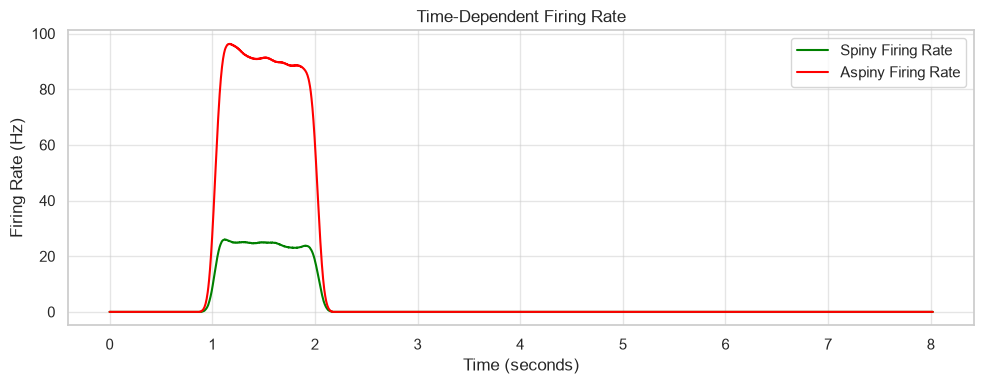

In [27]:
# We will use a Gaussian kernel to estimate the continuous firing rate
def calculate_firing_rate(peaks, total_samples, fs, sigma_ms=50):
    spike_train = np.zeros(total_samples)
    spike_train[peaks] = 1
    
    # Create Gaussian window
    sigma_samples = int(sigma_ms * 1e-3 * fs)
    window_size = sigma_samples * 6
    window = signal.windows.gaussian(window_size, std=sigma_samples)
    window /= window.sum() # Normalize integral to 1
    
    # Convolve spike train with window and multiply by fs to get Hz
    firing_rate = signal.convolve(spike_train, window, mode='same') * fs
    return firing_rate

sigma_ms = 50 # 50 ms window
spiny_rate_t = calculate_firing_rate(spiny_peaks, len(time_vector), fs, sigma_ms)
aspiny_rate_t = calculate_firing_rate(aspiny_peaks, len(time_vector), fs, sigma_ms)

plt.figure(figsize=(10, 4))
plt.plot(time_vector, spiny_rate_t, color='green', label='Spiny Firing Rate')
plt.plot(time_vector, aspiny_rate_t, color='red', label='Aspiny Firing Rate')
plt.title('Time-Dependent Firing Rate')
plt.xlabel('Time (seconds)')
plt.ylabel('Firing Rate (Hz)')
plt.legend()
plt.tight_layout()
plt.show()

**Kernel / Window Choice:**
We used a **Gaussian Kernel** (with a standard deviation $\sigma = 50$ ms). A Gaussian kernel is excellent for estimating continuous, time-dependent firing rates because it provides a smooth estimate, avoiding the blocky artifacts that a simple rectangular sliding window (boxcar filter) would produce. A 50 ms window smooths out individual discrete spikes while retaining the dynamic changes at the onset and offset of the stimulus.

Average Spiny Firing Rate: 25.00 Hz
Average Aspiny Firing Rate: 91.00 Hz


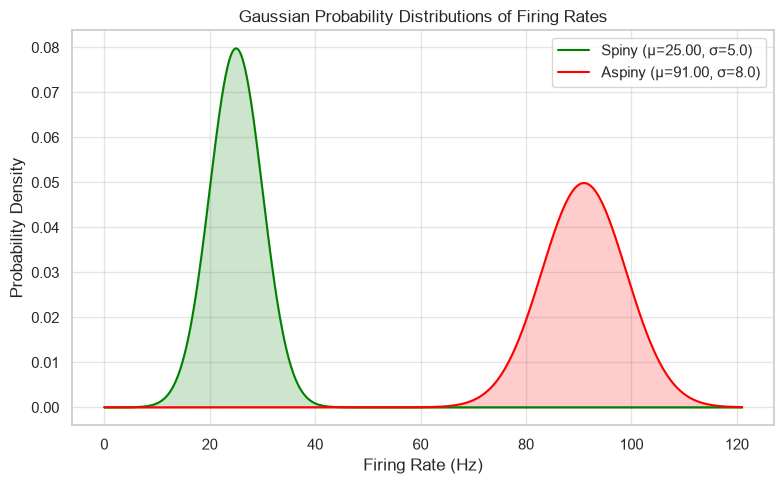

In [28]:
# Calculate average firing rate during the main stimulus duration
# The main stimulus (150 pA) occurs between ~1.02s and 2.02s
stim_start = 1.02
stim_end = 2.02
stim_duration = stim_end - stim_start

spiny_spikes_stim = len([p for p in spiny_peaks if stim_start * fs <= p <= stim_end * fs])
aspiny_spikes_stim = len([p for p in aspiny_peaks if stim_start * fs <= p <= stim_end * fs])

mu_spiny = spiny_spikes_stim / stim_duration
mu_aspiny = aspiny_spikes_stim / stim_duration

print(f"Average Spiny Firing Rate: {mu_spiny:.2f} Hz")
print(f"Average Aspiny Firing Rate: {mu_aspiny:.2f} Hz")

# Create Gaussian distributions with some chosen standard deviations for partial overlap
sigma_spiny = 5.0
sigma_aspiny = 8.0

x = np.linspace(0, mu_aspiny + 30, 1000)
pdf_spiny = norm.pdf(x, mu_spiny, sigma_spiny)
pdf_aspiny = norm.pdf(x, mu_aspiny, sigma_aspiny)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf_spiny, color='green', label=f'Spiny (μ={mu_spiny:.2f}, σ={sigma_spiny})')
plt.plot(x, pdf_aspiny, color='red', label=f'Aspiny (μ={mu_aspiny:.2f}, σ={sigma_aspiny})')
plt.fill_between(x, pdf_spiny, alpha=0.2, color='green')
plt.fill_between(x, pdf_aspiny, alpha=0.2, color='red')
plt.title('Gaussian Probability Distributions of Firing Rates')
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

Chosen Classification Threshold (z): 58.00 Hz


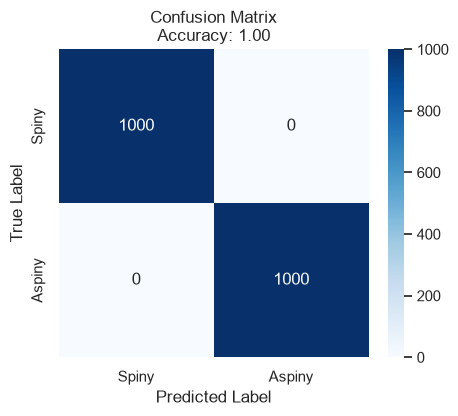

Accuracy: 1.00
Recall (Aspiny): 1.00
Recall (Spiny): 1.00


In [29]:
# Choose a threshold z where the two distributions intersect
z_threshold = (mu_spiny + mu_aspiny) / 2
print(f"Chosen Classification Threshold (z): {z_threshold:.2f} Hz")

# Generate synthetic test data to test the classifier based on distributions
np.random.seed(42)
N_samples = 1000
y_true = np.array([0]*N_samples + [1]*N_samples) # 0 for spiny, 1 for aspiny

test_spiny = np.random.normal(mu_spiny, sigma_spiny, N_samples)
test_aspiny = np.random.normal(mu_aspiny, sigma_aspiny, N_samples)
X_test = np.concatenate([test_spiny, test_aspiny])

# Predict: If rate > z_threshold, classify as aspiny (1)
y_pred = (X_test > z_threshold).astype(int)

# Evaluate
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
recall_aspiny = recall_score(y_true, y_pred)
recall_spiny = recall_score(y_true, y_pred, pos_label=0)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Spiny', 'Aspiny'], yticklabels=['Spiny', 'Aspiny'])
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"Accuracy: {acc:.2f}")
print(f"Recall (Aspiny): {recall_aspiny:.2f}")
print(f"Recall (Spiny): {recall_spiny:.2f}")

**Classifier Analysis:**
We chose a threshold $z$ situated roughly halfway between the two means to minimize overall error. Rates below $z$ are classified as Spiny, and above $z$ as Aspiny. 
*   **Confusion Matrix:** Shows the breakdown of correct predictions vs errors.
*   **Accuracy:** Shows a high overall correctness of the theoretical classifier.
*   **Recall:** Evaluates the ability to correctly identify all instances of a particular class. Because of the partial overlap in the chosen standard deviations, some Spiny neurons that randomly fire faster than usual will be misclassified as Aspiny (and vice versa).

In [30]:
# Choose 5 relevant firing rates around the overlapping region
rates_to_test = np.linspace(mu_spiny, mu_aspiny, 5)

print(f"{'Rate (Hz)':<15} | {'LR (Aspiny/Spiny)':<20} | {'Classification'}")
print("-" * 55)

for r in rates_to_test:
    p_spiny = norm.pdf(r, mu_spiny, sigma_spiny)
    p_aspiny = norm.pdf(r, mu_aspiny, sigma_aspiny)
    
    likelihood_ratio = p_aspiny / p_spiny
    
    # Classify based on LR > 1
    classification = "Aspiny" if likelihood_ratio > 1 else "Spiny"
    
    print(f"{r:<15.2f} | {likelihood_ratio:<20.4f} | {classification}")

Rate (Hz)       | LR (Aspiny/Spiny)    | Classification
-------------------------------------------------------
25.00           | 0.0000               | Spiny
41.50           | 0.0000               | Spiny
58.00           | 363009.3501          | Aspiny
74.50           | 142809499651275390976.0000 | Aspiny
91.00           | 42816905930329265343276900133447401472.0000 | Aspiny


**Likelihood Ratio Analysis:**
The Likelihood Ratio (LR) is defined as $P(\text{Rate} \mid \text{Aspiny}) / P(\text{Rate} \mid \text{Spiny})$.
*   If $LR > 1$, it means the observed firing rate is more likely to have come from an Aspiny neuron.
*   If $LR < 1$, it means it is more likely to be a Spiny neuron.

**What changes in the data could alter these values?**
1.  **Mean Firing Rate Shift:** If the true average firing rate ($\mu$) of either neuron changes due to variations in the stimulus intensity, the distributions will shift, drastically changing the likelihood ratios for these rates.
2.  **Variance Shift:** If the variance ($\sigma^2$) in the firing rate of the neurons increases (e.g., due to higher experimental or biological noise), the distributions become wider. This increases the overlap, making the likelihood ratio approach $1$ for a wider range of rates, which makes distinguishing the two neurons much harder.